In [ ]:
# Pure Monte Carlo estimation of E[Regret(ALG, y^n)] vs p in [0, 0.5]
# Algorithms: FTL, Cover, SMART
#
# Inner MC (K): averages over algorithm randomness (ties & Cover's hallucinated future)
# Outer MC (M): averages over data y^n ~ Bern(p)^n
#
# Outputs:
#   - regret_results_half_empirical.csv
#   - expected_regret_vs_p_half_empirical.png

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config (tweak as needed)
# -----------------------------
n = 1000                               # horizon
M = 400                                  # outer Monte Carlo samples per p (data randomness)
K = 32                                    # inner Monte Carlo runs per path (algorithm randomness)
p_grid = np.linspace(0.0, 0.5, 41)       # p in [0, 0.5]
rng = np.random.default_rng(12345)

# SMART threshold tau = sqrt(n/(2*pi)); switch when zero_crossings > tau
tau = math.sqrt(n / (2.0 * math.pi))

# -----------------------------
# Utilities
# -----------------------------
def const_best(y):
    ones = int(y.sum())
    return min(ones, len(y) - ones)

def predict_ftl_step(a, b, rng):
    """FTL: majority of past; tie -> fair coin."""
    if a > b:   return 1
    if a < b:   return 0
    return rng.integers(0, 2)  # 0 or 1 w.p. 1/2

def predict_cover_step(a, b, L, rng):
    """
    Cover at a step: hallucinate X ~ Binomial(L, 1/2),
    compare a+X vs b+(L-X); tie -> fair coin.
    """
    if L == 0:
        # reduces to FTL tie rule on empty future
        return predict_ftl_step(a, b, rng)
    X = rng.binomial(L, 0.5)
    ones_total = a + X
    zeros_total = b + (L - X)
    if ones_total > zeros_total:  return 1
    if ones_total < zeros_total:  return 0
    return rng.integers(0, 2)

def mistakes_ftl_one_run(y, rng):
    """Simulate one run of FTL (random ties)."""
    a = b = 0
    mistakes = 0
    for t in range(len(y)):
        yhat = predict_ftl_step(a, b, rng)
        mistakes += (yhat != y[t])
        if y[t] == 1: a += 1
        else:         b += 1
    return mistakes

def mistakes_cover_one_run(y, rng):
    """Simulate one run of Cover (fresh hallucinated future per step)."""
    a = b = 0
    mistakes = 0
    n_local = len(y)
    for t in range(n_local):
        L = n_local - (t + 1)
        yhat = predict_cover_step(a, b, L, rng)
        mistakes += (yhat != y[t])
        if y[t] == 1: a += 1
        else:         b += 1
    return mistakes

def mistakes_smart_one_run(y, tau, rng):
    """
    SMART:
      - start FTL
      - count zero crossings: times t where history (y_1..y_{t-1}) has equal #0s and #1s
        (t=1 counts by convention)
      - once crossings > tau, switch permanently to Cover
    """
    a = b = 0
    mistakes = 0
    n_local = len(y)
    zero_crossings = 1  # t=1 by convention (empty history equal)
    switched = False

    for t in range(n_local):
        if (a == b) and (t > 0):
            zero_crossings += 1
        if (not switched) and (zero_crossings > tau):
            switched = True

        if not switched:
            yhat = predict_ftl_step(a, b, rng)
        else:
            L = n_local - (t + 1)
            yhat = predict_cover_step(a, b, L, rng)

        mistakes += (yhat != y[t])
        if y[t] == 1: a += 1
        else:         b += 1

    return mistakes

def avg_mistakes_over_inner_runs(y, algo, K, tau, rng):
    """Average mistakes over K inner runs for a fixed path y (algorithm randomness)."""
    # Use independent streams for inner runs
    total = 0.0
    for k in range(K):
        # advance/derive a fresh RNG for reproducibility isolation
        sub_rng = np.random.default_rng(rng.integers(0, 2**63-1))
        if algo == "FTL":
            total += mistakes_ftl_one_run(y, sub_rng)
        elif algo == "Cover":
            total += mistakes_cover_one_run(y, sub_rng)
        elif algo == "SMART":
            total += mistakes_smart_one_run(y, tau, sub_rng)
        else:
            raise ValueError("Unknown algo")
    return total / K

def regret_for_path(y, algo, K, tau, rng):
    mistakes_mean = avg_mistakes_over_inner_runs(y, algo, K, tau, rng)
    return mistakes_mean - const_best(y)

# -----------------------------
# Outer Monte Carlo over y ~ Bern(p)^n
# -----------------------------
rows = []
for p in p_grid:
    # common-random-numbers for all three algs at this p (reduces variance)
    # we’ll reuse the same y-samples across FTL/Cover/SMART
    y_samples = rng.binomial(1, p, size=(M, n)).astype(np.int8)

    reg_ftl   = np.empty(M, dtype=np.float64)
    reg_cover = np.empty(M, dtype=np.float64)
    reg_smart = np.empty(M, dtype=np.float64)

    for i in range(M):
        # independent RNG for each path’s inner runs (but shared across algs to correlate)
        path_rng = np.random.default_rng(rng.integers(0, 2**63-1))
        y = y_samples[i]
        reg_ftl[i]   = regret_for_path(y, "FTL",   K, tau, path_rng)
        reg_cover[i] = regret_for_path(y, "Cover", K, tau, path_rng)
        reg_smart[i] = regret_for_path(y, "SMART", K, tau, path_rng)

    def mean_ci(x):
        mean = x.mean()
        se   = x.std(ddof=1) / math.sqrt(len(x))
        lo   = mean - 1.96 * se
        hi   = mean + 1.96 * se
        return mean, lo, hi

    mF, loF, hiF = mean_ci(reg_ftl)
    mC, loC, hiC = mean_ci(reg_cover)
    mS, loS, hiS = mean_ci(reg_smart)

    rows.append(dict(
        p=p,
        E_regret_FTL=mF,   lo_FTL=loF,   hi_FTL=hiF,
        E_regret_Cover=mC, lo_Cover=loC, hi_Cover=hiC,
        E_regret_SMART=mS, lo_SMART=loS, hi_SMART=hiS,
        Std_regret_FTL=reg_ftl.std(ddof=1),
        Std_regret_Cover=reg_cover.std(ddof=1),
        Std_regret_SMART=reg_smart.std(ddof=1),
        M=M, K=K, n=n
    ))

df = pd.DataFrame(rows)

# -----------------------------
# Plot with 95% confidence bands
# -----------------------------
plt.figure(figsize=(8,5))

def plot_with_band(x, y, lo, hi, label):
    plt.plot(x, y, label=label)
    plt.fill_between(x, lo, hi, alpha=0.2)

plot_with_band(df["p"], df["E_regret_FTL"],   df["lo_FTL"],   df["hi_FTL"],   "FTL")
plot_with_band(df["p"], df["E_regret_Cover"], df["lo_Cover"], df["hi_Cover"], "Cover")
plot_with_band(df["p"], df["E_regret_SMART"], df["lo_SMART"], df["hi_SMART"], "SMART")

plt.xlabel("p")
plt.ylabel("Estimated E[Regret(ALG, y^n)]")
plt.title(f"Expected Regret vs p in [0, 0.5], n = 1000")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("expected_regret_vs_p_half_empirical.png", dpi=150)
plt.show()

print("Saved: regret_results_half_empirical.csv, expected_regret_vs_p_half_empirical.png")

In [ ]:
# Regret vs c for y = (01)^c 0^(n-2c), n = 1000, c = 1..50
# PURE Monte Carlo over algorithm randomness only
# SMART switches when zero_crossings > 2 * sqrt(n/(2π))
#
# Outputs:
#   - CSV: regret_vs_c_n1000_empirical_1to50.csv
#   - PNG: regret_vs_c_n1000_plot_1to50.png

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
n = 1000
c_list = list(range(1, 75))    # c = 1..50
K = 500                         # inner MC runs per (algo, c); increase for smoother estimates
seed = 20250917
rng = np.random.default_rng(seed)

# Thresholds
tau_base   = math.sqrt(n / (2.0 * math.pi))   # for horizontal reference lines
tau_switch = 2.0 * tau_base                   # SMART switchpoint

print(f"n={n}, tau_base≈{tau_base:.4f}, SMART switch at tau_switch=2*tau_base≈{tau_switch:.4f}")

# -----------------------------
# Helpers
# -----------------------------
def build_sequence(n: int, c: int) -> np.ndarray:
    """y = (01)^c followed by zeros to length n."""
    assert 0 <= c <= n // 2
    alt = np.tile(np.array([0, 1], dtype=np.int8), c)
    tail = np.zeros(n - 2 * c, dtype=np.int8)
    return np.concatenate([alt, tail], axis=0)

def const_best(y: np.ndarray) -> int:
    """Best constant predictor in hindsight (mistake count)."""
    ones = int(y.sum())
    return min(ones, len(y) - ones)

def predict_ftl_step(a: int, b: int, r: np.random.Generator) -> int:
    """FTL: majority of past; ties -> fair coin."""
    if a > b:   return 1
    if a < b:   return 0
    return r.integers(0, 2)

def predict_cover_step(a: int, b: int, L: int, r: np.random.Generator) -> int:
    """
    Cover at step t:
      - sample hallucinated X ~ Binomial(L, 1/2)
      - compare a+X vs b+(L-X); ties -> fair coin
    """
    if L == 0:
        return predict_ftl_step(a, b, r)
    X = r.binomial(L, 0.5)
    ones_total = a + X
    zeros_total = b + (L - X)
    if ones_total > zeros_total:  return 1
    if ones_total < zeros_total:  return 0
    return r.integers(0, 2)

def mistakes_ftl_one_run(y: np.ndarray, r: np.random.Generator) -> int:
    a = b = 0
    mistakes = 0
    for t in range(len(y)):
        yhat = predict_ftl_step(a, b, r)
        mistakes += (yhat != y[t])
        if y[t] == 1: a += 1
        else:         b += 1
    return mistakes

def mistakes_cover_one_run(y: np.ndarray, r: np.random.Generator) -> int:
    a = b = 0
    mistakes = 0
    n_local = len(y)
    for t in range(n_local):
        L = n_local - (t + 1)
        yhat = predict_cover_step(a, b, L, r)
        mistakes += (yhat != y[t])
        if y[t] == 1: a += 1
        else:         b += 1
    return mistakes

def mistakes_smart_one_run(y: np.ndarray, tau_switch: float, r: np.random.Generator) -> int:
    """
    SMART (updated):
      - start FTL
      - zero crossings: times t where history (y_1..y_{t-1}) has equal #0s and #1s
        (t=1 counts by convention)
      - switch permanently to Cover as soon as zero_crossings > tau_switch,
        where tau_switch = 2*sqrt(n/(2π))
    """
    a = b = 0
    mistakes = 0
    n_local = len(y)
    zero_crossings = 1  # t=1 by convention (empty history equal)
    switched = False

    for t in range(n_local):
        if (a == b) and (t > 0):
            zero_crossings += 1
        if (not switched) and (zero_crossings > tau_switch):
            switched = True

        if not switched:
            yhat = predict_ftl_step(a, b, r)
        else:
            L = n_local - (t + 1)
            yhat = predict_cover_step(a, b, L, r)

        mistakes += (yhat != y[t])
        if y[t] == 1: a += 1
        else:         b += 1

    return mistakes

def avg_mistakes_over_K(y: np.ndarray, algo: str, K: int, tau_switch: float,
                        master_rng: np.random.Generator) -> float:
    """Average mistakes over K inner runs for fixed y (algorithm randomness only)."""
    total = 0.0
    for _ in range(K):
        sub_r = np.random.default_rng(master_rng.integers(0, 2**63 - 1))
        if algo == "FTL":
            total += mistakes_ftl_one_run(y, sub_r)
        elif algo == "Cover":
            total += mistakes_cover_one_run(y, sub_r)
        elif algo == "SMART":
            total += mistakes_smart_one_run(y, tau_switch, sub_r)
        else:
            raise ValueError("Unknown algo")
    return total / K

# -----------------------------
# Compute regrets for c = 1..50
# -----------------------------
rows = []
for c in c_list:
    y = build_sequence(n, c)
    baseline = const_best(y)
    crn = np.random.default_rng(rng.integers(0, 2**63 - 1))  # common-random-numbers across algos

    m_ftl   = avg_mistakes_over_K(y, "FTL",   K, tau_switch, crn)
    m_cover = avg_mistakes_over_K(y, "Cover", K, tau_switch, crn)
    m_smart = avg_mistakes_over_K(y, "SMART", K, tau_switch, crn)

    rows.append({
        "n": n, "c": c, "K": K,
        "tau_base": tau_base,
        "tau_switch": tau_switch,
        "Regret_FTL":   m_ftl   - baseline,
        "Regret_Cover": m_cover - baseline,
        "Regret_SMART": m_smart - baseline,
        "Baseline_best_constant": baseline
    })

df = pd.DataFrame(rows).sort_values("c")
df.to_csv("regret_vs_c_n1000_empirical_1to50.csv", index=False)
print(df[["c","Regret_FTL","Regret_Cover","Regret_SMART"]].round(3))

# -----------------------------
# Plot (with HORIZONTAL lines at tau_base and 2*tau_base) — NO markers
# -----------------------------
y_tex = r"$y=(01)^c\,0^{n-2c}$"

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df["c"], df["Regret_FTL"],   label="FTL",   linewidth=2)
ax.plot(df["c"], df["Regret_Cover"], label="Cover", linewidth=2)
ax.plot(df["c"], df["Regret_SMART"], label="SMART", linewidth=2)

# Horizontal reference lines (units of regret)
ax.axhline(tau_base,  linestyle="--", linewidth=1, color="gray", alpha=0.9,
           label=r"$\sqrt{n/(2\pi)}$")
ax.axhline(2*tau_base, linestyle="--", linewidth=1, color="gray", alpha=0.9,
           label=r"$2\sqrt{n/(2\pi)}$")

ax.set_xlabel("c (number of zero crossings)")
ax.set_ylabel("Regret")
ax.set_title(f"Regret vs c for {y_tex}   (n={n})")
ax.legend(loc="best")
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)

fig.tight_layout()
fig.savefig("regret_vs_c_n1000_plot_1to50.png", dpi=150)
plt.show()

print("Saved: regret_vs_c_n1000_empirical_1to50.csv, regret_vs_c_n1000_plot_1to50.png")

n=1000, tau_base≈12.6157, SMART switch at tau_switch=2*tau_base≈25.2313


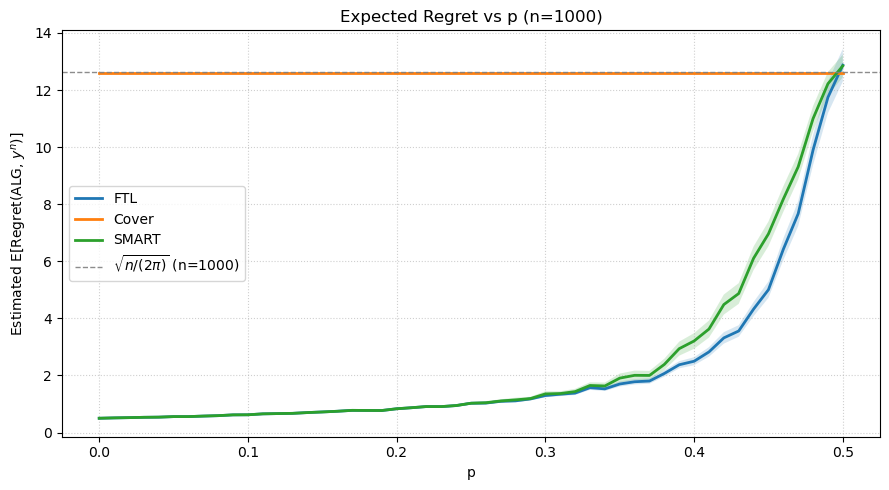

Saved plot -> expected_regret_vs_p_half_plot.png


In [26]:
# Plot E[Regret] vs p from regret_results_half.csv
# - Shows FTL, Cover, SMART curves
# - Uses 95% CI bands if lo_* / hi_* columns exist
# - Adds HORIZONTAL lines at sqrt(n/(2π)) and 2*sqrt(n/(2π)) with n=1000

import math
import pandas as pd
import matplotlib.pyplot as plt

# -------- settings --------
csv_path = "regret_results_half.csv"      # change if needed
png_path = "expected_regret_vs_p_half_plot.png"
n_for_lines = 1000                        # <- per your instruction for the horizontal lines
# --------------------------

df = pd.read_csv(csv_path)

# Helper to flexibly find columns by candidate names
def find_col(candidates):
    for name in candidates:
        if name in df.columns:
            return name
    return None

# Required x-axis
p_col = find_col(["p", "P"])
if p_col is None:
    raise ValueError("Couldn't find a 'p' column in the CSV.")

# Mean regret columns (any of these names will work)
FTL_mean   = find_col(["E_regret_FTL", "Regret_FTL", "mean_FTL", "ftl_mean"])
Cover_mean = find_col(["E_regret_Cover", "Regret_Cover", "mean_Cover", "cover_mean"])
SMART_mean = find_col(["E_regret_SMART", "Regret_SMART", "mean_SMART", "smart_mean"])

if not any([FTL_mean, Cover_mean, SMART_mean]):
    raise ValueError("Couldn't find mean regret columns for FTL/Cover/SMART.")

# Optional CI columns
FTL_lo   = find_col(["lo_FTL", "FTL_lo", "ci_lo_FTL"])
FTL_hi   = find_col(["hi_FTL", "FTL_hi", "ci_hi_FTL"])
Cover_lo = find_col(["lo_Cover", "Cover_lo", "ci_lo_Cover"])
Cover_hi = find_col(["hi_Cover", "Cover_hi", "ci_hi_Cover"])
SMART_lo = find_col(["lo_SMART", "SMART_lo", "ci_lo_SMART"])
SMART_hi = find_col(["hi_SMART", "SMART_hi", "ci_hi_SMART"])

# Compute the horizontal reference lines using n = 1000 (fixed per your request)
tau = math.sqrt(n_for_lines / (2.0 * math.pi))
tau2 = 2.0 * tau

# -------- plot --------
fig, ax = plt.subplots(figsize=(9, 5))

def plot_with_optional_band(x, y, lo, hi, label):
    ax.plot(x, y, label=label, linewidth=2)
    if lo is not None and hi is not None:
        ax.fill_between(x, lo, hi, alpha=0.18)

x = df[p_col]

if FTL_mean:
    plot_with_optional_band(x, df[FTL_mean],
                            df[FTL_lo] if FTL_lo in df.columns else None,
                            df[FTL_hi] if FTL_hi in df.columns else None,
                            "FTL")
if Cover_mean:
    plot_with_optional_band(x, df[Cover_mean],
                            df[Cover_lo] if Cover_lo in df.columns else None,
                            df[Cover_hi] if Cover_hi in df.columns else None,
                            "Cover")
if SMART_mean:
    plot_with_optional_band(x, df[SMART_mean],
                            df[SMART_lo] if SMART_lo in df.columns else None,
                            df[SMART_hi] if SMART_hi in df.columns else None,
                            "SMART")

# Horizontal guide lines at tau and 2*tau (n=1000)
ax.axhline(tau,  linestyle="--", linewidth=1, color="gray", alpha=0.9,
           label=r"$\sqrt{n/(2\pi)}$ (n=1000)")

ax.set_xlabel("p")
ax.set_ylabel("Estimated E[Regret(ALG, $y^n$)]")
ax.set_title("Expected Regret vs p (n=1000)")
ax.legend(loc="best")
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)

fig.tight_layout()
fig.savefig(png_path, dpi=150)
plt.show()

print(f"Saved plot -> {png_path}")